# **1. Data Collection**

### **1.1 Load Data**

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Major Project/0819_UkraineCombinedTweetsDeduped.csv"
df = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
df

,Unnamed: 0,userid,username,acctdesc,location,following,followers,totaltweets,usercreatedts,tweetid,...,original_tweet_userid,original_tweet_username,in_reply_to_status_id,in_reply_to_user_id,in_reply_to_screen_name,is_quote_status,quoted_status_id,quoted_status_userid,quoted_status_username,extractedts
0,0,173212647,JoeMokolobetsi,Yeshua Hamashiach is THE answer | Romans 10:9-...,Afrika Borwa,219,197,4789,2010-07-31 19:09:22.000000,1560416252937617411,...,0,NaN,0,0,NaN,False,0,0,NaN,2022-08-19 08:07:26.836769
1,1,335041409,XclusivasPuebla,Somos el periódico #ExclusivasPuebla| Investi...,"Puebla, México",1419,6402,70267,2011-07-14 02:02:24.000000,1560416256179707904,...,0,NaN,0,0,NaN,False,0,0,NaN,2022-08-19 07:51:50.523048
2,2,1512400441103032323,ShelterAnimalUA,Shelter for abandoned dogs and cats. 1400 dogs...,Ukraine,782,109,1198,2022-04-08 12:02:47.000000,1560416257752666113,...,0,NaN,0,0,NaN,False,0,0,NaN,2022-08-19 05:12:06.194216
3,3,1356632630662430722,DogandCatHelpe1,Shelter for abandoned dogs and cats. 1400 dogs...,Ukraine,5,39,690,2021-02-02 15:57:12.000000,1560416257790382081,...,0,NaN,0,0,NaN,False,0,0,NaN,2022-08-19 11:22:26.824532
4,4,20297125,ElMananaOnline,Las mejores noticias de los dos Laredos y el m...,Nuevo Laredo,2269,17978,56188,2009-02-07 06:32:49.000000,1560416257937051648,...,0,NaN,0,0,NaN,False,0,0,NaN,2022-08-19 11:52:29.448634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47989,47989,1553460900727853056,Ksana_tt_,"Рада всім українцям, бо #УкрТві неймовірний💙💛",🇺🇦,237,157,51,2022-07-30 19:22:33.000000,1560778594703577090,...,0,NaN,0,0,NaN,True,1560773862756851712,1593157274,igorlachenkov,2022-08-20 01:34:19.026497
47990,47990,132907794,krishtopa,Процедурно згенерований мешканець Всесвіту,Львів/ Сєвєродонецьк,687,488,23608,2010-04-14 14:01:46.000000,1560778614169288705,...,0,NaN,1560778126619299840,34132596,dosnostalgic,False,0,0,NaN,2022-08-20 01:33:03.111239
47991,47991,14445094,El_Ciudadano,https://t.co/hF7jqSE6Tk medio de comunicación ...,Santiago de Chile,71965,553230,226276,2008-04-19 17:43:02.000000,1560778618208342016,...,0,NaN,0,0,NaN,False,0,0,NaN,2022-08-20 00:52:50.050159
47992,47992,1382090090059534336,ElCiudadano_Mx,Prensa libertaria en Puebla ¿Tienes alguna den...,"Puebla, México",461,1109,30631,2021-04-13 21:57:41.000000,1560778619428999168,...,0,NaN,0,0,NaN,False,0,0,NaN,2022-08-20 00:52:50.040182


# **2. Data Preprocessing**

### **2.1 Explore Data**

In [ ]:
print("=== Dataset Preview ===\n")
print(df.head())

print("\n=== Column Names ===\n")
print(df.columns)

print("\n=== Dataset Info ===\n")
print(df.info())

=== Dataset Preview ===

   Unnamed: 0               userid         username  \
0           0            173212647   JoeMokolobetsi   
1           1            335041409  XclusivasPuebla   
2           2  1512400441103032323  ShelterAnimalUA   
3           3  1356632630662430722  DogandCatHelpe1   
4           4             20297125   ElMananaOnline   

                                            acctdesc        location  \
0  Yeshua Hamashiach is THE answer | Romans 10:9-...    Afrika Borwa   
1  Somos el periódico  #ExclusivasPuebla| Investi...  Puebla, México   
2  Shelter for abandoned dogs and cats. 1400 dogs...         Ukraine   
3  Shelter for abandoned dogs and cats. 1400 dogs...         Ukraine   
4  Las mejores noticias de los dos Laredos y el m...    Nuevo Laredo   

   following  followers  totaltweets       usercreatedts              tweetid  \
0        219        197         4789 2010-07-31 19:09:22  1560416252937617411   
1       1419       6402        70267 2011-07-14 0

In [ ]:
datetime_cols = ["usercreatedts", "tweetcreatedts", "extractedts"]
for c in datetime_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

print("=== Date-Time Range Info ===")
for c in datetime_cols:
    if c in df.columns:
        col = df[c]
        print(f"\n[{c}]")
        print(f"  Non‑null: {col.notna().sum()} / {len(df)}")
        print(f"  Min:      {col.min()}")
        print(f"  Max:      {col.max()}")

=== Date-Time Range Info ===

[usercreatedts]
  Non‑null: 47994 / 47994
  Min:      2006-07-16 16:44:08
  Max:      2022-08-19 23:33:08

[tweetcreatedts]
  Non‑null: 47994 / 47994
  Min:      2022-08-19 00:00:00
  Max:      2022-08-19 23:59:57

[extractedts]
  Non‑null: 47994 / 47994
  Min:      2022-08-19 00:16:55.258603
  Max:      2022-08-20 01:35:11.291583


In [ ]:
print("=== Descriptive Statistics: Numeric ===\n")
print(df.describe(include=["int64", "float64"]))

print("\n=== Descriptive Statistics: Categorical/Text ===\n")
print(df.describe(include=["object", "bool"]))

=== Descriptive Statistics: Numeric ===

         Unnamed: 0        userid      following     followers   totaltweets  \
count  47994.000000  4.799400e+04   47994.000000  4.799400e+04  4.799400e+04   
mean   23996.500000  7.499381e+17    1530.501375  3.010692e+04  7.026632e+04   
std    13854.818747  6.738779e+17    5144.047245  4.226732e+05  2.368187e+05   
min        0.000000  1.378000e+03       0.000000  0.000000e+00  1.000000e+00   
25%    11998.250000  6.178539e+08      69.000000  9.600000e+01  2.105000e+03   
50%    23996.500000  9.232891e+17     339.000000  4.300000e+02  9.820000e+03   
75%    35994.750000  1.456627e+18    1181.000000  2.236750e+03  4.717600e+04   
max    47993.000000  1.560772e+18  237181.000000  1.829419e+07  4.114435e+06   

            tweetid  retweetcount  favorite_count  original_tweet_id  \
count  4.799400e+04  47994.000000    47994.000000            47994.0   
mean   1.560614e+18      1.442243        7.091532                0.0   
std    8.940039e+13   

In [ ]:
print("=== Per-Column Detailed Summary ===")
for col in df.columns:
    s = df[col]
    print(f"\n----- {col} -----")
    print(f"Dtype:         {s.dtype}")
    print(f"Non‑null:      {s.notna().sum()}")
    print(f"Null:          {s.isna().sum()}")
    print(f"Unique values: {s.nunique(dropna=True)}")

    if pd.api.types.is_numeric_dtype(s):
        print(f"Min:           {s.min()}")
        print(f"Max:           {s.max()}")
        print(f"Mean:          {s.mean()}")

    if pd.api.types.is_datetime64_any_dtype(s):
        print(f"Earliest:      {s.min()}")
        print(f"Latest:        {s.max()}")

    if pd.api.types.is_object_dtype(s) or s.dtype == bool:
        vc = s.value_counts(dropna=False).head(10)
        print("Top 10 values:")
        print(vc)

=== Per-Column Detailed Summary ===

----- Unnamed: 0 -----
Dtype:         int64
Non‑null:      47994
Null:          0
Unique values: 47994
Min:           0
Max:           47993
Mean:          23996.5

----- userid -----
Dtype:         int64
Non‑null:      47994
Null:          0
Unique values: 19995
Min:           1378
Max:           1560771783065731073
Mean:          7.49938056536839e+17

----- username -----
Dtype:         object
Non‑null:      47994
Null:          0
Unique values: 19999
Top 10 values:
username
FuckPutinBot       1432
bmurphypointman     312
rogue_corq          195
ArvadaRadio         184
crypt0nerd          183
arson_cole          179
schayno_karas       133
_Thirunarayan1      130
helply11            127
UkraineAlert        123
Name: count, dtype: int64

----- acctdesc -----
Dtype:         object
Non‑null:      43037
Null:          4957
Unique values: 17746
Top 10 values:
acctdesc
NaN                                                                                  

### **2.2 Language Detection**

In [ ]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=4e471b2865f9bc6024715e00c152f55f450b8182335bfd5a574b90f59c0e7411
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
from langdetect import detect, DetectorFactory
import pandas as pd

DetectorFactory.seed = 42

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return "unknown"

df['language'] = df['text'].apply(detect_language)

lang_map = {
    "en": "English",
    "de": "German",
    "fr": "French",
    "it": "Italian",
    "es": "Spanish",
    "fi": "Finnish",
    "et": "Estonian",
    "lt": "Lithuanian",
    "tr": "Turkish",
    "pt": "Portuguese",
    "no": "Norwegian",
    "pl": "Polish",
    "id": "Indonesian",
    "nl": "Dutch",
    "sw": "Swahili",
    "sl": "Slovenian",
    "ca": "Catalan",
    "hr": "Croatian",
    "af": "Afrikaans",
    "uk": "Ukrainian",
    "ru": "Russian",
    "ja": "Japanese",
    "zh": "Chinese",
    "in": "Indonesian",
    "el": "Greek",
    "hi": "Hindi",
    "ar": "Arabic",
    "ro": "Romanian",
    "bg": "Bulgarian",
    "und": "Undefined",
    "unknown": "Unknown"}

lang_counts = df['language'].value_counts().head(20)
language_series = pd.Series(lang_counts.index, index=lang_counts.index)
language_full_series = language_series.map(lang_map).fillna(language_series)
result = pd.DataFrame({'language': lang_counts.index, 'language_full': language_full_series.values, 'count': lang_counts.values})

print("Language Distribution (Top 20):\n")
print(result)

Language Distribution (Top 20):

   language language_full  count
0        en       English  26383
1        de        German   5118
2        uk     Ukrainian   2617
3        fr        French   2308
4        it       Italian   2048
5        es       Spanish   1573
6        et      Estonian   1427
7        ru       Russian   1245
8        tr       Turkish    390
9        fi       Finnish    359
10       ja      Japanese    322
11       bg     Bulgarian    312
12       pt    Portuguese    308
13       sl     Slovenian    257
14       nl         Dutch    252
15       pl        Polish    249
16       id    Indonesian    235
17       no     Norwegian    231
18       el         Greek    189
19       hr      Croatian    150


### **2.3 Data Cleaning**

In [ ]:
import re

def clean_tweet(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^A-Za-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

df['clean_text_original'] = df['text'].apply(clean_tweet)

### **2.4 Text Translation**

In [ ]:
!pip install googletrans==4.0.0rc1

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.0 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=9b684c01e7e10d7674722f0107603ea1f8356682fdcdda269e18aa8e6b29a5b8
  Stored in directory: /root/.cache/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperfram

In [ ]:
from googletrans import Translator
import time
import random

translator = Translator()

def translate_to_english(text):
    text = str(text).strip()
    if len(text) < 4:
        return text
    try:
        result = translator.translate(text, dest='en')
        time.sleep(random.uniform(0.25, 0.6))
        return result.text.strip()
    except Exception:
        time.sleep(1)
        return text

mask_non_en = df['language'] != 'en'
mask_en = df['language'] == 'en'

print("Total Tweets:", len(df))
print("English Tweets:", mask_en.sum())
print("Non-English Tweets:", mask_non_en.sum())
unique_non_en = df.loc[mask_non_en, 'text'].dropna().unique()
print("Unique Non-English Tweets to Translate:", len(unique_non_en))

translation_map = {}

for txt in unique_non_en:
    translation_map[txt] = translate_to_english(txt)

df.loc[mask_non_en, 'translated_text'] = df.loc[mask_non_en, 'text'].map(translation_map)
df.loc[mask_en, 'translated_text'] = df.loc[mask_en, 'text']
df['clean_text'] = df['translated_text'].apply(clean_tweet)

Total Tweets: 47994
English Tweets: 26383
Non-English Tweets: 21611
Unique Non-English Tweets to Translate: 21457


In [ ]:
def is_english_filter(text):
    words = str(text).split()

    if len(words) < 3:
        return False
    eng_words = len(words) * 0.3
    return sum(1 for w in words if len(w) > 2 and w.isalpha()) >= eng_words

df = df[df['clean_text'].apply(is_english_filter)].reset_index(drop=True)
df[['text', 'language_full', 'translated_text', 'clean_text']].head(20)

,text,language_full,translated_text,clean_text
0,Dear vaccine advocate\n\nDo take the COVID19 m...,English,Dear vaccine advocate\n\nDo take the COVID19 m...,dear vaccine advocate do take the covid19 mrna...
1,#Mundo \n\nAl menos 6 muertos y 16 heridos en ...,Spanish,#World\n\nAt least 6 dead and 16 injured in Ru...,world at least 6 dead and 16 injured in russia...
2,"Animal shelter Dogs and Cats, we need your hel...",English,"Animal shelter Dogs and Cats, we need your hel...",animal shelter dogs and cats we need your help...
3,"Welcome to our shelter!\nLocated in Ukraine, K...",English,"Welcome to our shelter!\nLocated in Ukraine, K...",welcome to our shelter located in ukraine kyiv...
4,"Tensión, debido a que #Rusia sigue en pie en l...",Spanish,"Tension, because #Russia is still standing at ...",tension because russia is still standing at th...
5,👇 Good news you may have missed: First @WFP sh...,English,👇 Good news you may have missed: First @WFP sh...,good news you may have missed first shipment o...
6,Opinion: The Ukraine war is also being fought ...,English,Opinion: The Ukraine war is also being fought ...,opinion the ukraine war is also being fought o...
7,"Ale Fuck tèt ou, Putin!\n(Haitian Creole)\n\n#...",English,"Ale Fuck tèt ou, Putin!\n(Haitian Creole)\n\n#...",ale fuck tt ou putin haitian creole istandwith...
8,"Ethereum's spot setup looks grim, but derivati...",English,"Ethereum's spot setup looks grim, but derivati...",ethereums spot setup looks grim but derivative...
9,"Artículo de #JeffreyDSachs. 👉 ""#Biden está lle...",Spanish,"Article by #JeffreyDSachs.👉 ""#Biden is leading...",article by jeffreydsachs biden is leading ukra...


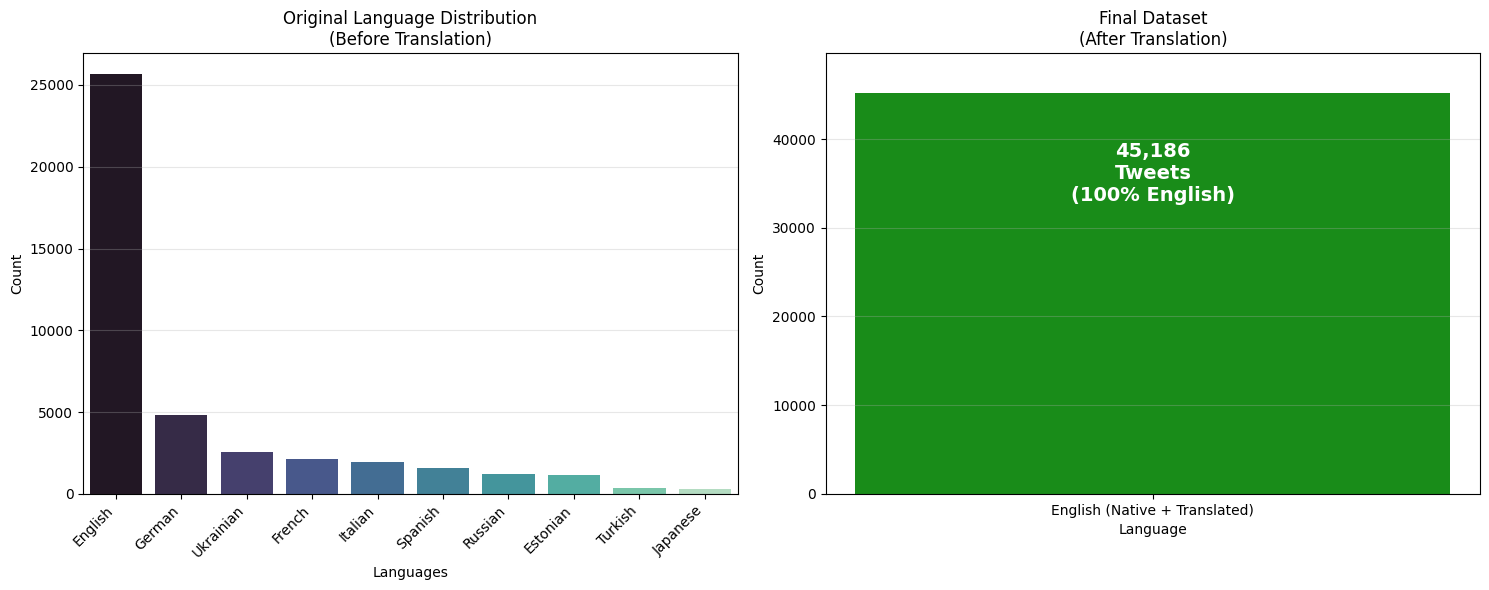


Language Translation Summary:

               Metric  Count Percentage
       Native English  25665        57%
Translated to English  19521        43%
  Total Final Dataset  45186       100%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=df['language_full'].value_counts().head(10).index, y=df['language_full'].value_counts().head(10).values, palette="mako")
plt.title('Original Language Distribution\n(Before Translation)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Count')
plt.xlabel('Languages')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.subplot(1, 2, 2)
plt.bar(['English (Native + Translated)'], [len(df)], color=['green'], alpha=0.9, linewidth=2)
plt.title('Final Dataset\n(After Translation)')
plt.ylabel('Count')
plt.xlabel('Language')
plt.ylim(0, len(df) * 1.1)
plt.text(0, len(df)*0.8, f'{len(df):,}\nTweets\n(100% English)', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nLanguage Translation Summary:\n")
original_counts = df['language'].value_counts()
native_english = len(df[df['language'] == 'en'])
translated_count = len(df) - native_english
total_final = len(df)

summary_table = pd.DataFrame({'Metric': ['Native English', 'Translated to English', 'Total Final Dataset'], 'Count': [native_english, translated_count, total_final], 'Percentage': [f"{native_english/len(df)*100:.0f}%", f"{translated_count/len(df)*100:.0f}%", "100%"]})
print(summary_table.to_string(index=False))


### **2.5 VADER (Valence Aware Dictionary and sEntiment Reasoner) Analyzer**

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.3 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
import numpy as np
from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
VADER_THRESHOLDS = {
    'neg_threshold': -0.03,
    'pos_threshold':  0.03,
    'neutral_range':  (0.03, 0.03)}

def vader_pipeline(df):
    pos, neg, neu, comp = [], [], [], []
    for i, text in enumerate(df['clean_text']):
        score = analyzer.polarity_scores(str(text))
        pos.append(score['pos'])
        neg.append(score['neg'])
        neu.append(score['neu'])
        comp.append(score['compound'])

    vader_df = pd.DataFrame({
        'VADER_Positive': pos,
        'VADER_Negative': neg,
        'VADER_Neutral': neu,
        'VADER_Compound': comp})

    df_vader = pd.concat([df.reset_index(drop=True), vader_df], axis=1)

    conditions = [
        df_vader['VADER_Compound'] <= VADER_THRESHOLDS['neg_threshold'],
        (df_vader['VADER_Compound'] > VADER_THRESHOLDS['neg_threshold']) &
        (df_vader['VADER_Compound'] < VADER_THRESHOLDS['pos_threshold']),
        df_vader['VADER_Compound'] >= VADER_THRESHOLDS['pos_threshold']]

    values = ['Negative', 'Neutral', 'Positive']
    df_vader['Category'] = np.select(conditions, values, default='Neutral')
    return df_vader

df_final = vader_pipeline(df)
df_final[['clean_text', 'language', 'Category', 'VADER_Compound']]

,clean_text,language,Category,VADER_Compound
0,dear vaccine advocate do take the covid19 mrna...,en,Negative,-0.6757
1,world at least 6 dead and 16 injured in russia...,es,Negative,-0.7906
2,animal shelter dogs and cats we need your help...,en,Positive,0.8225
3,welcome to our shelter located in ukraine kyiv...,en,Positive,0.6908
4,tension because russia is still standing at th...,es,Negative,-0.5423
...,...,...,...,...
45181,not about me because i would never dare fortun...,uk,Neutral,0.0000
45182,everything as usual just another russian gover...,en,Positive,0.4215
45183,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000
45184,roulette ep7 ukraine president zelensky the he...,es,Neutral,0.0000


### **2.6 Counts and Percentage Table for Categories**

In [ ]:
cat_count = df_final['Category'].value_counts()
cat_perc = 100 * cat_count / len(df_final)

sent_stat = pd.DataFrame({'Count': cat_count.values, 'Percentage': cat_perc.round().astype(int).astype(str) + '%'}, index=cat_count.index)
print(sent_stat)


          Count Percentage
Category                  
Negative  17500        39%
Positive  15084        33%
Neutral   12602        28%


### **2.7 Average Length and Word Count of Tweets**

In [ ]:
df_final['tweet_length'] = df_final['clean_text'].str.len()
df_final['word_count'] = df_final['clean_text'].str.split().str.len()

print(f"Average Tweet Length: {df_final['tweet_length'].mean():.0f} Characters")
print(f"Average Word Count:   {df_final['word_count'].mean():.0f}")
print(f"Length Range:         {df_final['tweet_length'].min():.0f} - {df_final['tweet_length'].max():.0f}")

Average Tweet Length: 150 Characters
Average Word Count:   23
Length Range:         7 - 611


### **2.8 Save Clean Data**

In [ ]:
cols = ['clean_text', 'language', 'Category', 'VADER_Compound']
df_final[cols].to_csv("/content/drive/My Drive/Major Project/clean_dataset.csv", index=False)

# **3. Exploratory Data Analysis (EDA)**

### **3.1 Data Vizualisation**

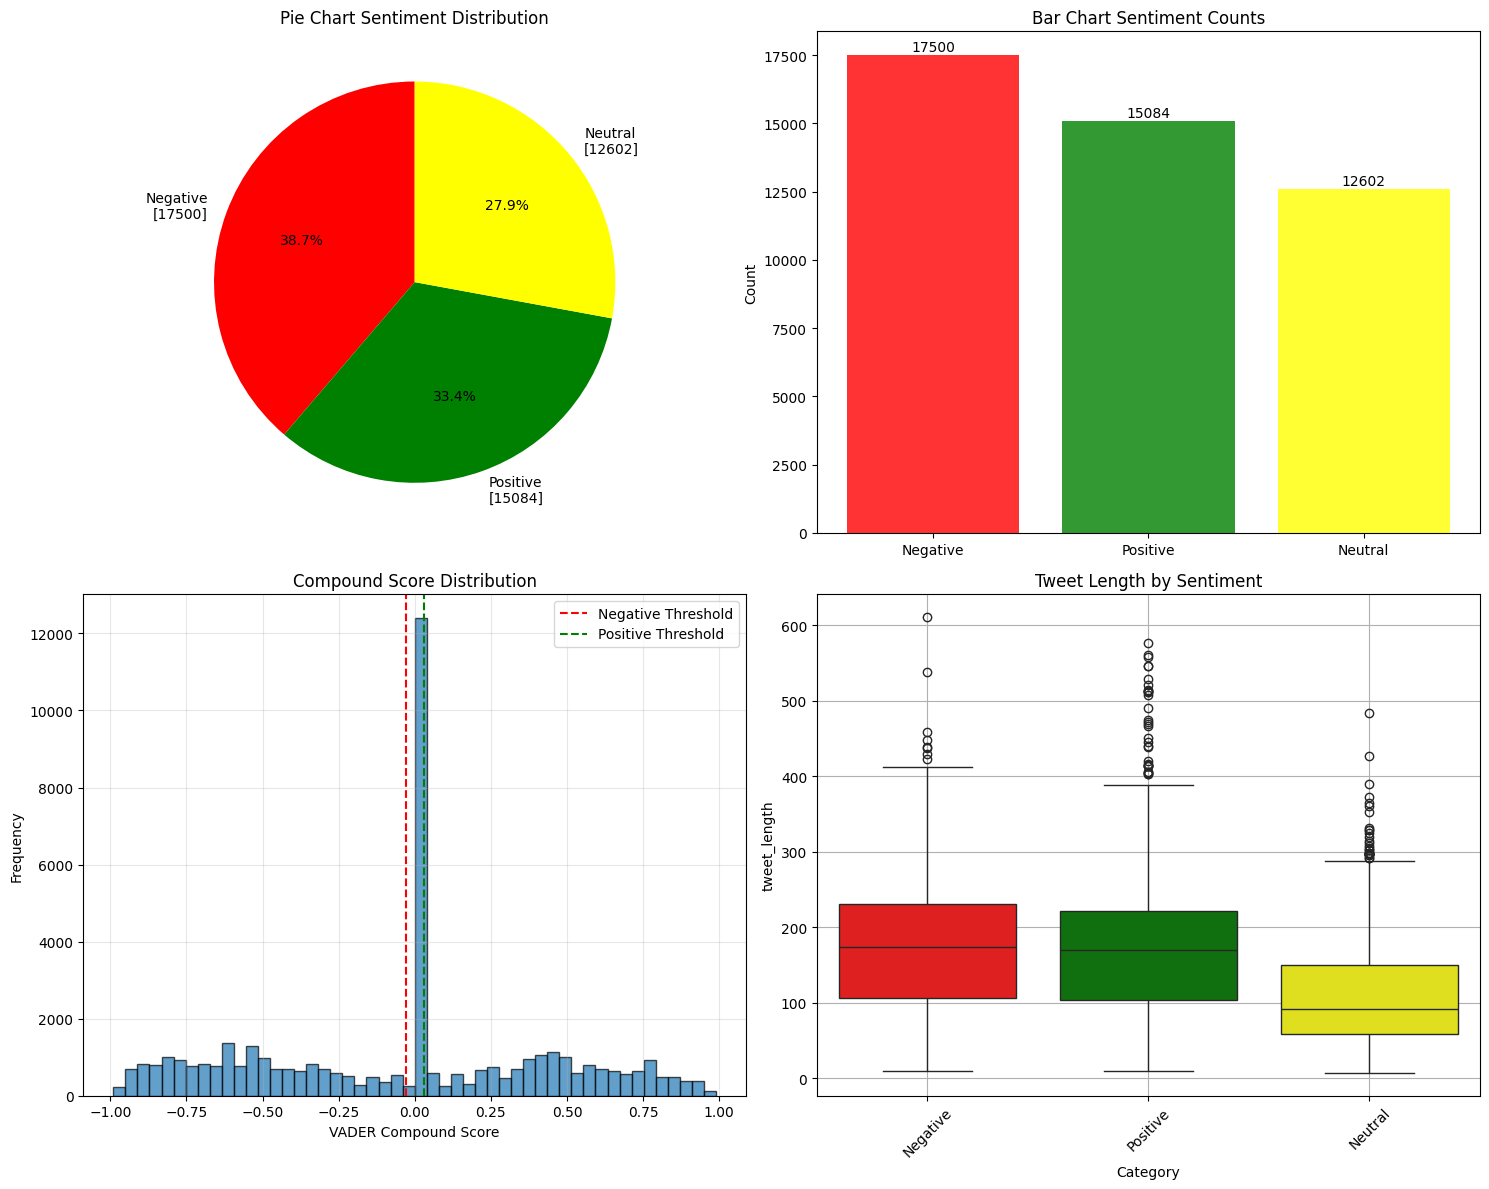

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
colors = ["red", "green", "yellow"]
labels_pie = [f"{cat}\n[{count}]" for cat, count in cat_count.items()]
axes[0,0].pie(cat_count.values, labels=labels_pie, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Pie Chart Sentiment Distribution')

bars = axes[0,1].bar(cat_count.index, cat_count.values, color=colors, alpha=0.8)
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Bar Chart Sentiment Counts')
for bar, count in zip(bars, cat_count.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(count), ha='center', va='bottom')

axes[1,0].hist(df_final['VADER_Compound'], bins=50, alpha=0.7, edgecolor='black')
axes[1,0].axvline(VADER_THRESHOLDS['neg_threshold'], color='red', linestyle='--', label='Negative Threshold')
axes[1,0].axvline(VADER_THRESHOLDS['pos_threshold'], color='green', linestyle='--', label='Positive Threshold')
axes[1,0].set_xlabel('VADER Compound Score')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Compound Score Distribution')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

sns.boxplot(data=df_final, x='Category', y='tweet_length', ax=axes[1,1], palette=colors)
axes[1,1].set_title('Tweet Length by Sentiment')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.grid()
plt.show()

### **3.2 Top 30 Positive Tweets**

In [ ]:
top_30_pos = df_final.nlargest(30, 'VADER_Compound')['clean_text']
print("Top 30 Positive Tweets:\n")
print(top_30_pos)

Top 30 Positive Tweets:

35935    thv sweet dreams good morning my love i adore ...
43286    its 121 am of saturday in lviv ukraine situati...
3692     life goes on and always lives no matter love l...
6137     sorry but surely you mean things are looking g...
35825    my sweet boy taehyung you are the only one lik...
3553     i congratulate you on the feast of the transfi...
29947    zdenka thank you dear zelda love you buncheshu...
4925     uaws beginner level winetasting course in yunn...
36991    follow me to 1800 free haircuts for the homele...
9267     courage lives in ukraine and love for independ...
38745    glory to ukraine glory to the heroes pray for ...
25121    china is a marvelous place and few people own ...
24931    im very happy if you like it a big thank you i...
7282     good morning yaroslava amp wwkindnessbrigade a...
13428    but youre welcome a big thank you i wish you a...
33733    its not easy to earn animals attraction but th...
40882    grateful to read this 

### **3.3 Top 30 Negative Tweet**

In [ ]:
top_30_neg = df_final.nsmallest(30, 'VADER_Compound')['clean_text']
print("Top 30 Negative Tweets:\n")
print(top_30_neg)

Top 30 Negative Tweets:

39346    a fat motherfucker kills tortures tortures a b...
2525     ukrainerussiawar war brings not only death but...
12034    russiaisaterroriststate armukrainenow russia m...
15178    i cant believe that after all the horrors deat...
39027    the ruins of the city abandoned apocalypse apo...
8942     but no the damned west is still trying to dest...
8473     im tired of the terrorist state continuing to ...
6558     no one will win this war but the countries usa...
7500     nato is not a sewing club but has been and is ...
2773     you are full of you bring nothing but death an...
5472     chancellor scholz not only shakes hands with h...
44443    who helps you fight environmental injustice ar...
9769     the second dad killed a skunk in izyum today i...
17078    6 theres a moral argument for southeast asian ...
22212    having to remind for months that the fckptn an...
7072     news i heard you fail to evacuate your russian...
31008    the main person respon

### **3.4 Top 30 Tweets with Maximum Numbers of Retweets**

In [ ]:
if 'retweetcount' in df_final.columns:
    top_30_rt = df_final.sort_values('retweetcount', ascending=False)['clean_text'].head(30)
    print("Top 30 Tweets with Maximum Numbers of Retweets:\n")
    print(top_30_rt)
else:
    print('No column retweetcount found')

Top 30 Tweets with Maximum Numbers of Retweets:

12967    yesterday a wellknown ukrainian twitter user d...
16295    video by govua about real nuclear threat for a...
35509    does macron want warhe said we have become a n...
41873          ukrainian troops getting trained in britain
24408    great victory clearing this farmers field of m...
35847    massive explosions in sevastopol a key very ke...
39003    here is macron one of the main responsible for...
861      russia 6 hired couriers were caught trying to ...
38681    this macron responsible for the war in ukraine...
14008    unusual russia will offer the ruble equivalent...
4767     yulia chaika a young and beautiful defender of...
9899     yes there are some specifically talented ukrai...
23039    russia continues to shell kharkiv daily the ci...
39532    ukraine the ukrainian forces received the most...
41201    macron evokes the war that thunders at our doo...
4338     dear all international students thank you for ...
1956   

### **3.5 Visualization of Sentiment and Compound Scores of Positive, Neutral and Negative Tweets**

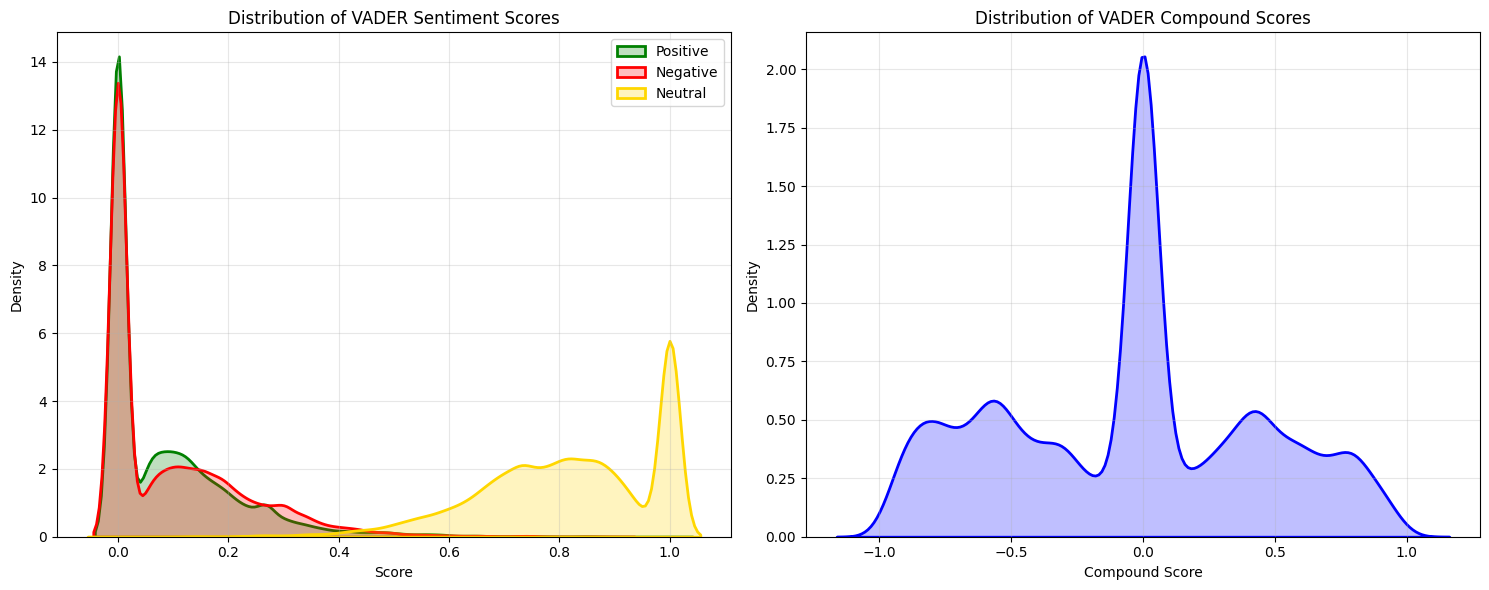

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.kdeplot(df_final['VADER_Positive'], label='Positive', color='green', fill=True, linewidth=2, ax=axes[0])
sns.kdeplot(df_final['VADER_Negative'], label='Negative', color='red', fill=True, linewidth=2, ax=axes[0])
sns.kdeplot(df_final['VADER_Neutral'],  label='Neutral',  color='gold', fill=True, linewidth=2, ax=axes[0])

axes[0].set_title('Distribution of VADER Sentiment Scores')
axes[0].set_xlabel('Score')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.kdeplot(df_final['VADER_Compound'], color='blue', fill=True, linewidth=2, ax=axes[1])
axes[1].set_title('Distribution of VADER Compound Scores')
axes[1].set_xlabel('Compound Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### **3.6 WordCloud for All Sentiments**

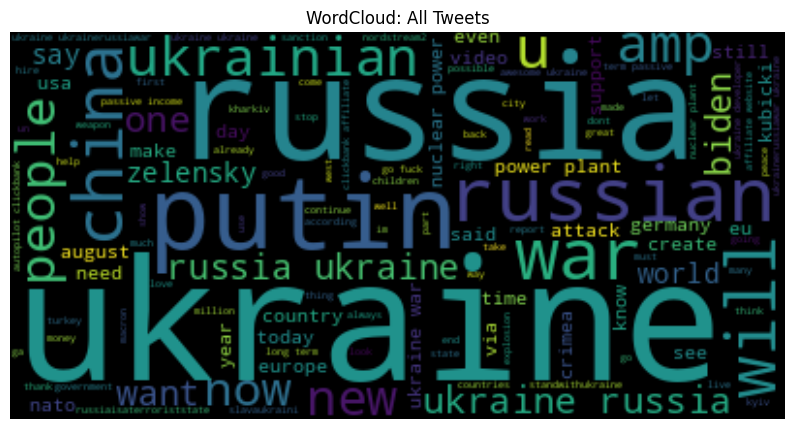

In [ ]:
from wordcloud import WordCloud, STOPWORDS

all_text = ' '.join(df['clean_text'])
wordcloud_all = WordCloud(stopwords=STOPWORDS, background_color='black').generate(all_text)

plt.figure(figsize=(10,7)); plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis('off'); plt.title('WordCloud: All Tweets'); plt.show()

### **3.7 WordCloud for Positive Sentiments**

In [ ]:
from wordcloud import WordCloud, STOPWORDS

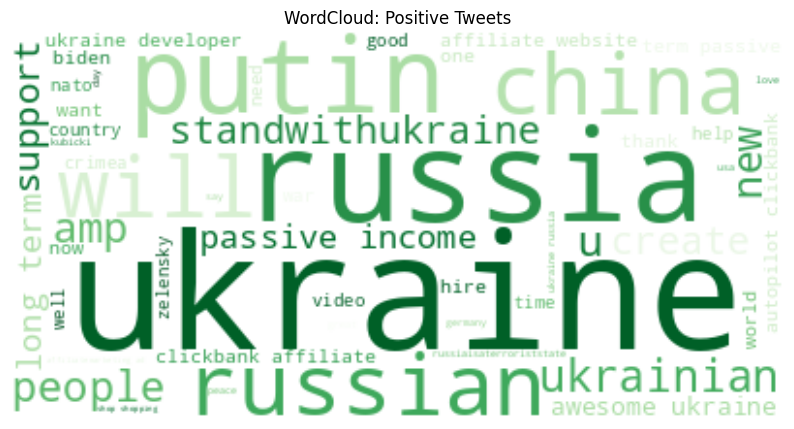

In [ ]:
text_pos = ' '.join(df_final[df_final['Category']=='Positive']['clean_text'])
wordcloud_pos = WordCloud(stopwords=STOPWORDS,background_color='white',colormap='Greens').generate(text_pos)

plt.figure(figsize=(10,7)); plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off'); plt.title('WordCloud: Positive Tweets'); plt.show()

### **3.8 WordCloud for Negative Sentiments**

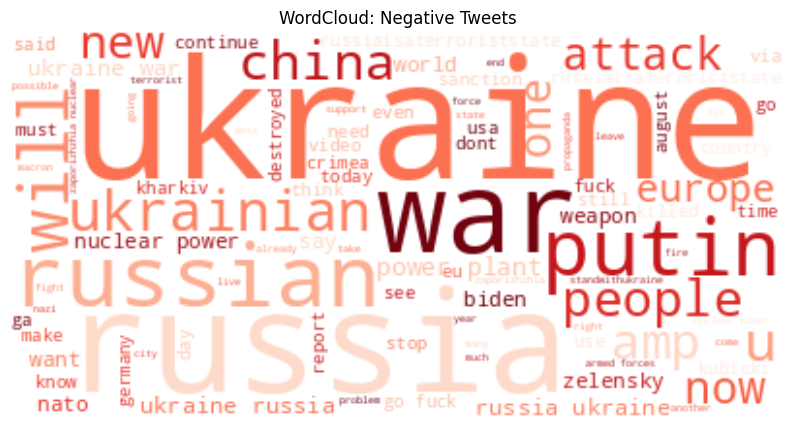

In [ ]:
text_neg = ' '.join(df_final[df_final['Category']=='Negative']['clean_text'])
wordcloud_neg = WordCloud(stopwords=STOPWORDS,background_color='white',colormap='Reds').generate(text_neg)

plt.figure(figsize=(10,7)); plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off'); plt.title('WordCloud: Negative Tweets'); plt.show()

### **3.9 WordCloud for Neutral Sentiments**

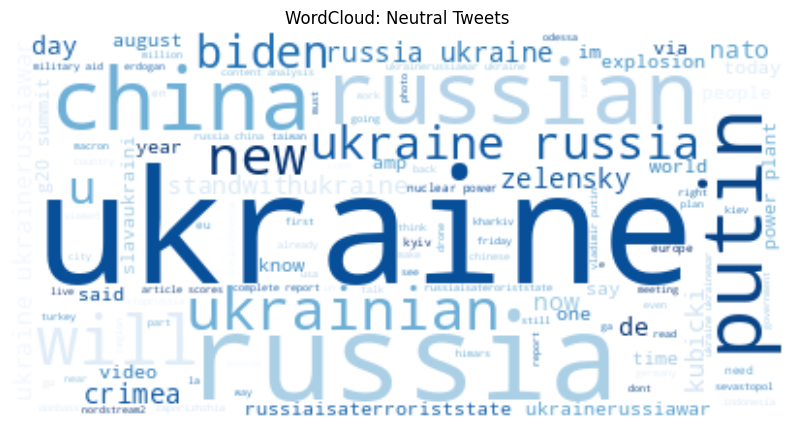

In [ ]:
text_neu = ' '.join(df_final[df_final['Category']=='Neutral']['clean_text'])
wordcloud_neu = WordCloud(stopwords=STOPWORDS,background_color='white',colormap='Blues').generate(text_neu)

plt.figure(figsize=(10,7)); plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.axis('off'); plt.title('WordCloud: Neutral Tweets'); plt.show()

### **3.10 Collect Positive Hashtags from Tweets**

In [ ]:
def extract_hashtags(text):
    return re.findall(r'#(\w+)', text)

df_final['hashtags'] = df_final['text'].apply(extract_hashtags)
pos_ht = sum(df_final[df_final['Category']=='Positive']['hashtags'],[])
print('Top 30 Positive Hashtags:\n', pd.Series(pos_ht).value_counts().head(30))

Top 30 Positive Hashtags:
 Ukraine                    4479
Russia                     1737
Putin                      1185
China                      1055
StandWithUkraine            939
UkraineRussiaWar            732
Biden                       564
Affiliate                   509
Russian                     440
affiliate                   440
Kubicki                     428
USA                         416
RussiaIsATerroristState     410
SlavaUkraini                398
business                    359
ukraine                     356
twitter                     344
NATO                        343
affiliatemarketing          330
gifts                       324
socialmedia                 323
shopping                    322
ad                          322
gift                        319
shop                        318
deal                        317
bitcoin                     315
Crimea                      308
affiliateprogram            296
ArmUkraineNow               294
Name: count, 

### **3.11 Collect Negative Hashtags from Tweets**

In [ ]:
neg_ht = sum(df_final[df_final['Category']=='Negative']['hashtags'],[])
print('Top 30 Negative Hashtags:\n', pd.Series(neg_ht).value_counts().head(30))

Top 30 Negative Hashtags:
 Ukraine                    5525
Russia                     2650
Putin                      1590
UkraineRussiaWar           1223
RussiaIsATerroristState    1101
StandWithUkraine            894
China                       835
war                         758
Russian                     725
Biden                       633
russiaisateroriststate      622
ukraine                     604
UkraineWar                  469
USA                         446
russia                      445
NATO                        428
RussianWarCrimes            424
Zelensky                    413
Ucrania                     382
Kubicki                     382
UkraineUnderAttack          359
Russland                    348
Rusia                       336
Crimea                      330
War                         302
SlavaUkraini                300
Ukrainian                   293
Zaporizhzhia                267
Kharkiv                     261
RussiaUkraineWar            257
Name: count, 

### **3.12 Influence Analysis by Followers Reached Across Sentiment Category**

In [ ]:
followers_by_sentiment = df_final.groupby('Category')['followers'].sum().reindex(['Positive','Negative','Neutral'])
print(followers_by_sentiment)

Category
Positive    578193141
Negative    566333030
Neutral     294254309
Name: followers, dtype: int64


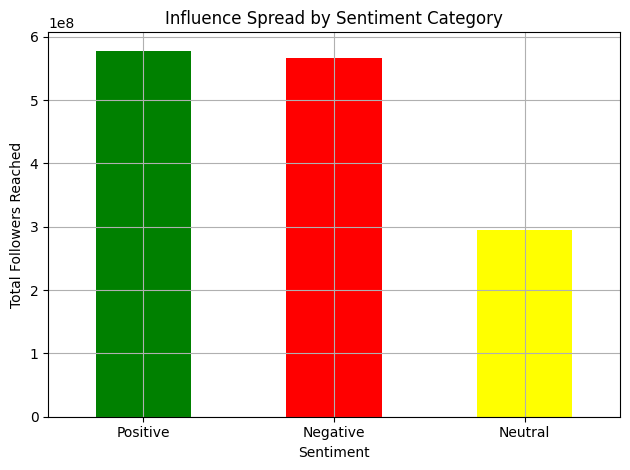

In [ ]:
followers_by_sentiment.plot(kind='bar', color=['green', 'red', 'yellow'])

plt.title('Influence Spread by Sentiment Category')
plt.ylabel('Total Followers Reached')
plt.xlabel('Sentiment')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid()
plt.show()

### **3.13 Comparison of Sentiment Score of Tweets by Indian, Ukraine and from Other Countries**

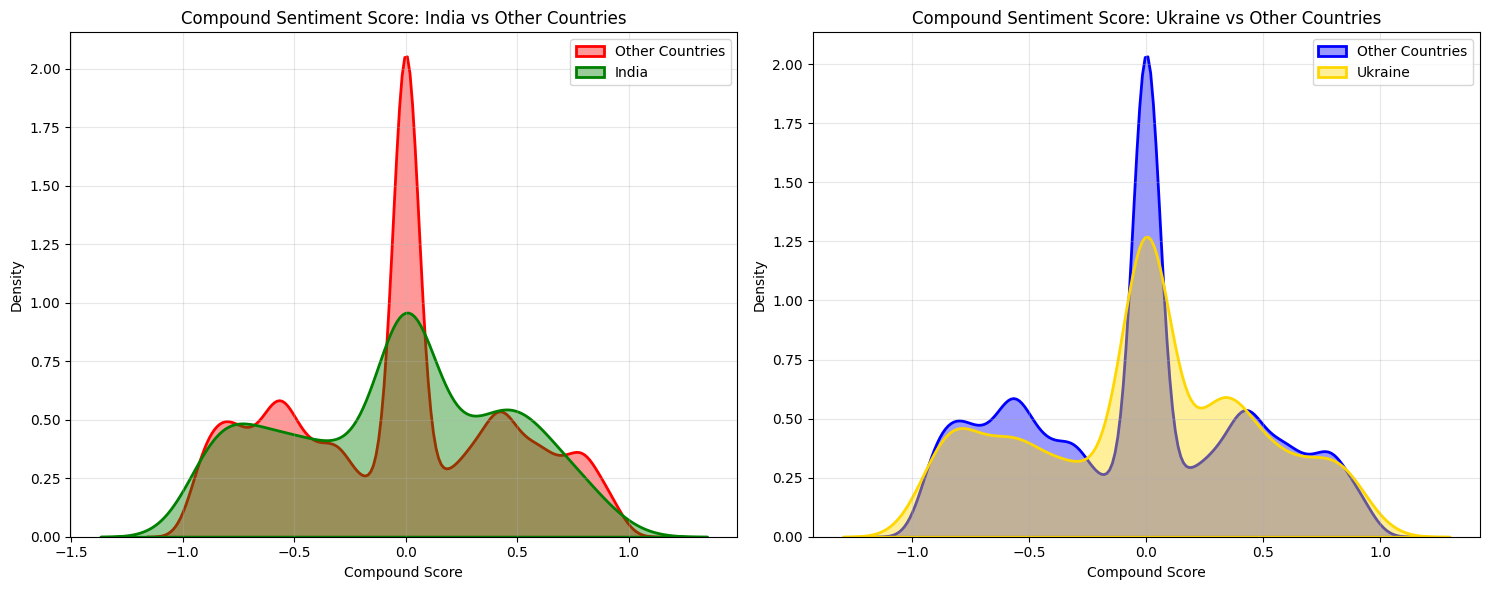

In [ ]:
df_final['location'] = df_final['location'].fillna('')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.kdeplot(df_final[~df_final['location'].str.contains('india', case=False, na=False)]['VADER_Compound'], fill=True, color='red', linewidth=2, alpha=0.4, label='Other Countries', ax=axes[0])
sns.kdeplot(df_final[df_final['location'].str.contains('india', case=False, na=False)]['VADER_Compound'], fill=True, color='green', linewidth=2, alpha=0.4, label='India', ax=axes[0])

axes[0].set_title('Compound Sentiment Score: India vs Other Countries')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

sns.kdeplot(df_final[~df_final['location'].str.contains('ukraine', case=False, na=False)]['VADER_Compound'], fill=True, color='blue', linewidth=2, alpha=0.4, label='Other Countries', ax=axes[1])
sns.kdeplot(df_final[df_final['location'].str.contains('ukraine', case=False, na=False)]['VADER_Compound'], fill=True, color='gold', linewidth=2, alpha=0.4, label='Ukraine', ax=axes[1])

axes[1].set_title('Compound Sentiment Score: Ukraine vs Other Countries')
axes[1].set_xlabel('Compound Score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()